# Supplements

## Cluster LOCO-Split's target of estimation

### Gaussian Mixture example

Gaussian mixture with $K=3$ clusters from $$y \sim \text{Mult}(\pi,1)$$ 
$$X|y=k \sim N(\mu_k, \sigma^2 I_2) \in \mathbb{R}^{N \times 2}$$
where $\pi = \begin{pmatrix} 1/3 & 1/3 & 1/3 \end{pmatrix}^T$, and $\mu = \begin{pmatrix} 1 & 1 \\ 3 & 4 \\ 4 & 1\end{pmatrix}$

In [43]:
from pathlib import Path

import numpy as np
import pandas as pd


results_dir = Path("../../ClusterLOCO-Inference/results/cluster_loco_matched_targets")
raw_files = [results_dir / "sample_size/raw_results.csv", results_dir / "variance/raw_results.csv"]
missing = [path for path in raw_files if not path.exists()]
if missing:
    raise FileNotFoundError(f"Missing result files: {missing}")

results_df = pd.concat([pd.read_csv(path) for path in raw_files], ignore_index=True)
# Keep only each method's corresponding population target.
results_df = results_df[results_df["matched_target"].eq(1)].copy()

In [44]:
identity_columns = ["sweep_mode", "N", "variance", "replication", "feature", "error_metric", "method", "oracle_target"]

duplicates = results_df.duplicated(identity_columns, keep=False)

if duplicates.any():
    duplicate_rows = (results_df.loc[duplicates, identity_columns].sort_values(identity_columns))
    raise ValueError(f"Duplicate replication-level results found:\n {duplicate_rows.head(20)}")

In [45]:
group_columns = ["sweep_mode", "sweep_value", "N", "variance", "feature", "error_metric", "method", "oracle_target"]

summary_df = (results_df.groupby(group_columns, as_index=False)
    .agg(coverage=("covered", "mean"), coverage_count=("covered", "sum"), replications=("covered", "size"),
        mean_length=("interval_length", "mean"), length_sd=("interval_length", "std"),
        mean_estimate=("estimate", "mean"), estimate_sd=("estimate", "std"), mean_model_se=("standard_error", "mean"),
        mean_oracle=("oracle_loco", "mean"), mean_oracle_se=("oracle_standard_error", "mean")))

summary_df["coverage_mcse"] = np.sqrt(summary_df["coverage"] * (1 - summary_df["coverage"]) / summary_df["replications"])
summary_df["length_mcse"] = (summary_df["length_sd"] / np.sqrt(summary_df["replications"]))
summary_df["estimate_mcse"] = (summary_df["estimate_sd"] / np.sqrt(summary_df["replications"]))

### Coverage given variance 

In [46]:
import pandas as pd
sum_df = summary_df #pd.read_csv('./data/GMM_summary_results.csv', index_col=None)
sum_df.head()

,sweep_mode,sweep_value,N,variance,feature,error_metric,method,oracle_target,coverage,coverage_count,...,mean_length,length_sd,mean_estimate,estimate_sd,mean_model_se,mean_oracle,mean_oracle_se,coverage_mcse,length_mcse,estimate_mcse
0,sample_size,300.0,300,1.5,0,giq,Cluster LOCO,Cluster LOCO target,0.13,13,...,0.065080,0.002836,0.262960,0.029080,0.019783,0.202974,0.002019,0.033630,0.000284,0.002908
1,sample_size,300.0,300,1.5,0,giq,LOCO,LOCO target,0.89,89,...,0.069571,0.002458,0.227434,0.021205,0.021148,0.231502,0.002002,0.031289,0.000246,0.002121
2,sample_size,300.0,300,1.5,0,giq,Stochastic Cluster LOCO,Stochastic Cluster LOCO target,0.77,77,...,0.068961,0.002486,0.227689,0.028024,0.020963,0.225473,0.002001,0.042083,0.000249,0.002802
3,sample_size,300.0,300,1.5,1,giq,Cluster LOCO,Cluster LOCO target,0.18,18,...,0.066754,0.003083,0.274643,0.027988,0.020292,0.217503,0.002027,0.038419,0.000308,0.002799
4,sample_size,300.0,300,1.5,1,giq,LOCO,LOCO target,0.83,83,...,0.069830,0.002314,0.243366,0.024546,0.021227,0.245725,0.002007,0.037563,0.000231,0.002455


In [47]:
sum_df.N.unique(), sum_df.variance.unique()

(array([ 300,  500, 1000, 2000, 4000, 8000]),
 array([1.5, 0.1, 0.5, 1. , 2. , 2.5, 3. ]))

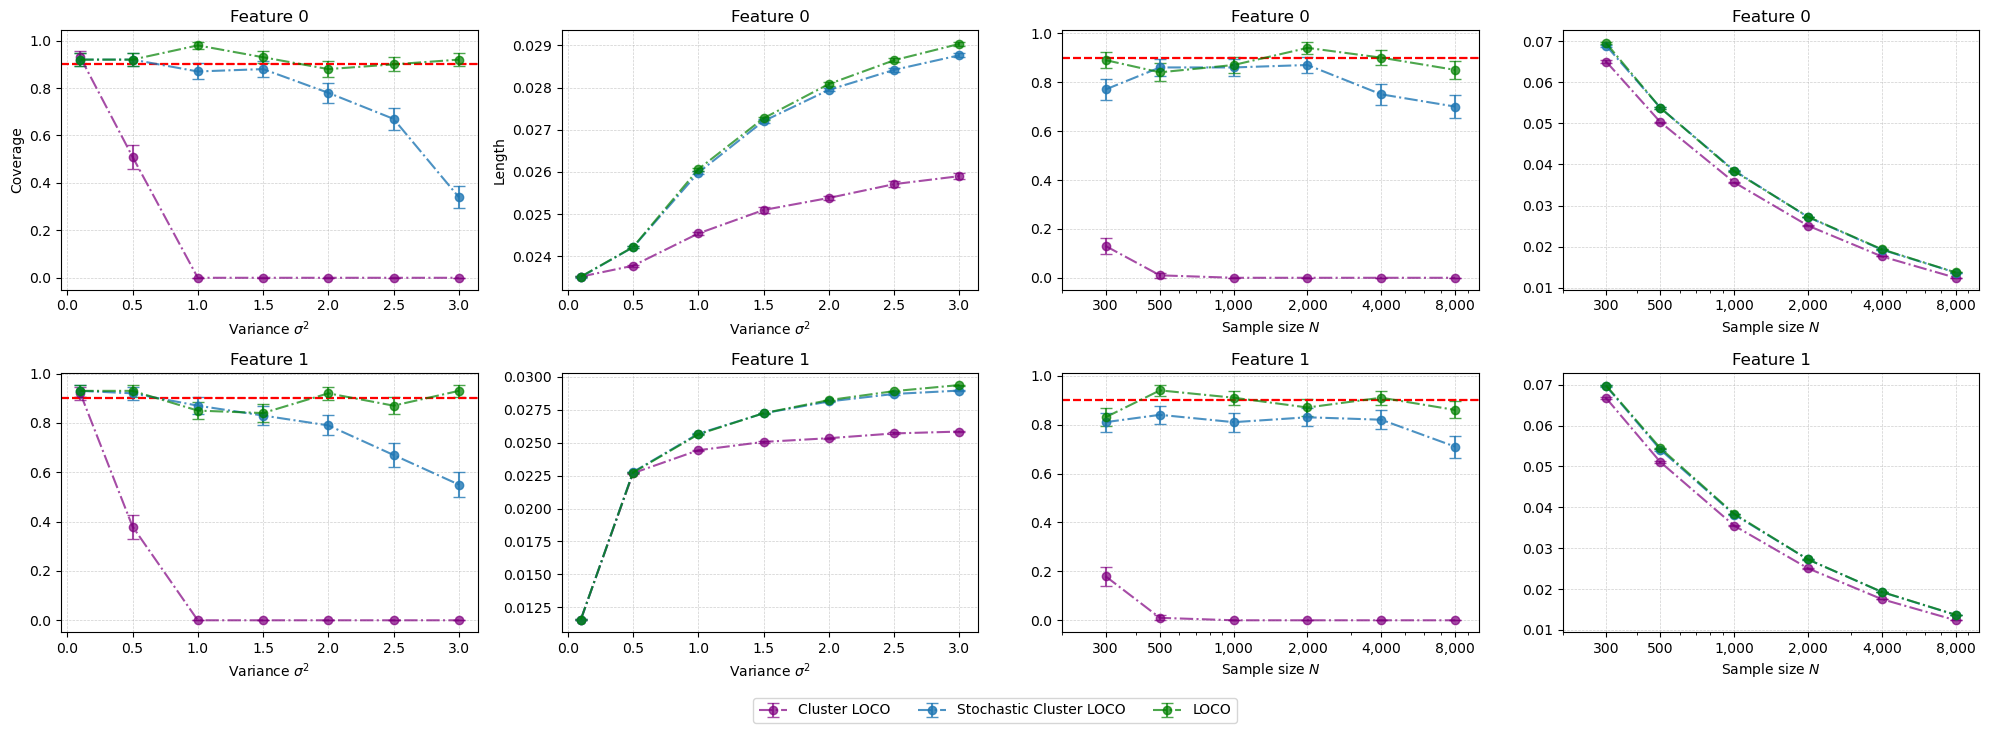

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

fig, ax = plt.subplots(2, 4, figsize=(20, 7), sharex=False)
methods = ['Cluster LOCO', 'Stochastic Cluster LOCO', "LOCO"]
method_styles = {"Cluster LOCO": {"color": "purple", "alpha": 0.7},
    "Stochastic Cluster LOCO": {"color": "tab:blue", "alpha": 0.8},
    "LOCO": {"color": "green", "alpha": 0.7}}

for method in methods:
    for i in range(2):
        plot_df = sum_df[(sum_df.sweep_mode == 'variance') & (sum_df.N == 2000) & (sum_df.feature == i)]
        method_df = plot_df[plot_df.method == method].sort_values('variance').groupby('variance')[['coverage','coverage_mcse', 'mean_length', 'length_mcse']].mean().reset_index()
        kwargs = {"fmt": "o-.", "capsize": 4, "color": method_styles[method]["color"], "alpha": method_styles[method]["alpha"], "label": method}
        ax[i, 0].errorbar(method_df['variance'],  method_df['coverage'], yerr=method_df['coverage_mcse'].fillna(0), **kwargs)
        ax[i, 0].axhline(y=0.90, linestyle='--', color='red')
        ax[i, 1].errorbar(method_df['variance'],  method_df['mean_length'], yerr=method_df['length_mcse'].fillna(0), **kwargs)
        for j in range(2):
            ax[i, j].set_xlabel(f"Variance $\sigma^2$")
            ax[i, j].set_title(f"Feature {i}")
            ax[i, j].grid(linestyle="--", linewidth=0.5, alpha=0.6)

        plot_df = sum_df[(sum_df.sweep_mode == 'sample_size')  & (sum_df.variance == 1.5) & (sum_df.feature == i)]
        method_df = plot_df[plot_df.method == method].sort_values('N').groupby('N')[['coverage','coverage_mcse', 'mean_length', 'length_mcse']].mean().reset_index()
        ax[i, 2].errorbar(method_df['N'],  method_df['coverage'], yerr=method_df['coverage_mcse'].fillna(0), **kwargs)
        ax[i, 2].axhline(y=0.90, linestyle='--', color='red')
        ax[i, 3].errorbar(method_df['N'],  method_df['mean_length'], yerr=method_df['length_mcse'].fillna(0), **kwargs)
        for j in [2, 3]:
            ax[i, j].set_xlim(200, 10000)
            ax[i, j].set_xscale('log')
            ax[i, j].set_xlabel(f"Sample size $N$")
            ax[i, j].set_title(f"Feature {i}")
            ax[i, j].grid(linestyle="--", linewidth=0.5, alpha=0.6)
            ax[i, j].set_xticks(np.sort(method_df['N'].unique()))
            ax[i, j].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
            # Hide minor tick labels between the selected values.
            ax[i, j].xaxis.set_minor_formatter(NullFormatter())
            
    ax[0, 0].set_ylabel("Coverage")
    ax[0, 1].set_ylabel("Length")

handles, labels = ax[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5,-0.05),)
fig.tight_layout()

In [38]:
sum_df.head()

,sweep_mode,sweep_value,N,variance,feature,error_metric,method,oracle_target,coverage,coverage_count,...,mean_length,length_sd,mean_estimate,estimate_sd,mean_model_se,mean_oracle,mean_oracle_se,coverage_mcse,length_mcse,estimate_mcse
0,sample_size,300.0,300,1.5,0,giq,Cluster LOCO,Cluster LOCO target,0.13,13,...,0.065080,0.002836,0.262960,0.029080,0.019783,0.202974,0.002019,0.033630,0.000284,0.002908
1,sample_size,300.0,300,1.5,0,giq,LOCO,LOCO target,0.89,89,...,0.069571,0.002458,0.227434,0.021205,0.021148,0.231502,0.002002,0.031289,0.000246,0.002121
2,sample_size,300.0,300,1.5,0,giq,Stochastic Cluster LOCO,Stochastic Cluster LOCO target,0.77,77,...,0.068961,0.002486,0.227689,0.028024,0.020963,0.225473,0.002001,0.042083,0.000249,0.002802
3,sample_size,300.0,300,1.5,1,giq,Cluster LOCO,Cluster LOCO target,0.18,18,...,0.066754,0.003083,0.274643,0.027988,0.020292,0.217503,0.002027,0.038419,0.000308,0.002799
4,sample_size,300.0,300,1.5,1,giq,LOCO,LOCO target,0.83,83,...,0.069830,0.002314,0.243366,0.024546,0.021227,0.245725,0.002007,0.037563,0.000231,0.002455


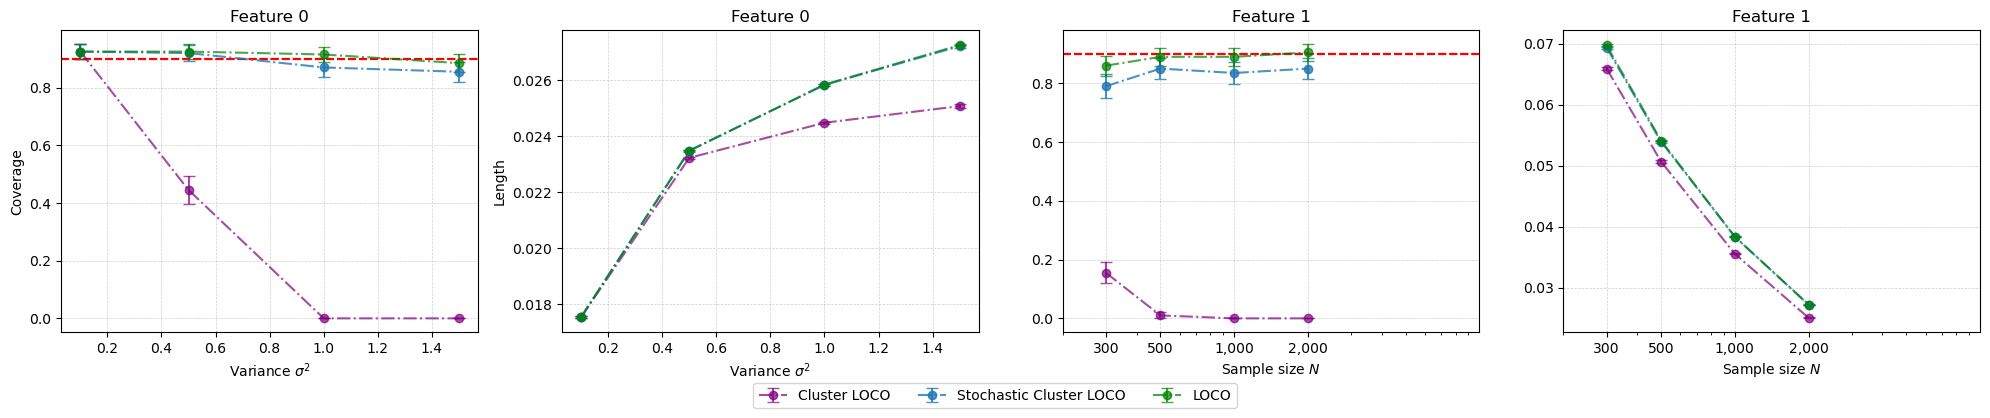

In [41]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter

fig, ax = plt.subplots(1, 4, figsize=(20, 4), sharex=False)
methods = ['Cluster LOCO', 'Stochastic Cluster LOCO', "LOCO"]
method_styles = {"Cluster LOCO": {"color": "purple", "alpha": 0.7},
    "Stochastic Cluster LOCO": {"color": "tab:blue", "alpha": 0.8},
    "LOCO": {"color": "green", "alpha": 0.7}}

# sum_df = sum_df.groupby(['feature', 'variance', 'N', 'method']).mean().reset_index()
for method in methods:
    plot_df = sum_df[(sum_df.sweep_mode == 'variance') & (sum_df.N == 2000)]
    method_df = plot_df[plot_df.method == method].sort_values('variance').groupby('variance')[['coverage','coverage_mcse', 'mean_length', 'length_mcse']].mean().reset_index()
    kwargs = {"fmt": "o-.", "capsize": 4, "color": method_styles[method]["color"], "alpha": method_styles[method]["alpha"], "label": method}
    ax[0].errorbar(method_df['variance'],  method_df['coverage'], yerr=method_df['coverage_mcse'].fillna(0), **kwargs)
    ax[0].axhline(y=0.90, linestyle='--', color='red')
    ax[1].errorbar(method_df['variance'],  method_df['mean_length'], yerr=method_df['length_mcse'].fillna(0), **kwargs)
    for j in range(2):
        ax[j].set_xlabel(f"Variance $\sigma^2$")
        ax[j].set_title(f"Feature 0")
        ax[j].grid(linestyle="--", linewidth=0.5, alpha=0.6)

    plot_df = sum_df[(sum_df.sweep_mode == 'sample_size')  & (sum_df.variance == 1.5)]
    method_df = plot_df[plot_df.method == method].sort_values('N').groupby('N')[['coverage','coverage_mcse', 'mean_length', 'length_mcse']].mean().reset_index()
    ax[2].errorbar(method_df['N'],  method_df['coverage'], yerr=method_df['coverage_mcse'].fillna(0), **kwargs)
    ax[2].axhline(y=0.90, linestyle='--', color='red')
    ax[3].errorbar(method_df['N'],  method_df['mean_length'], yerr=method_df['length_mcse'].fillna(0), **kwargs)
    for j in [2, 3]:
        ax[j].set_xlim(200, 10000)
        ax[j].set_xscale('log')
        ax[j].set_xlabel(f"Sample size $N$")
        ax[j].set_title(f"Feature 1")
        ax[j].grid(linestyle="--", linewidth=0.5, alpha=0.6)
        ax[j].set_xticks(np.sort(method_df['N'].unique()))
        ax[j].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:,.0f}"))
        # Hide minor tick labels between the selected values.
        ax[j].xaxis.set_minor_formatter(NullFormatter())
        
ax[0].set_ylabel("Coverage")
ax[1].set_ylabel("Length")

handles, labels = ax[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, bbox_to_anchor=(0.5,-0.05),)
fig.tight_layout()

### Confidence intervals

In [260]:
raw_df = pd.read_csv('./data/GMM_results.csv', index_col=0)
np.sort(raw_df.variance.unique())

array([0.1, 0.5, 1. , 1.5, 2. , 2.5, 3. ])

In [261]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_interval_oracle(plot_df, features=[0, 1], rng=np.random.default_rng(24), ax=None, method_order=method_order, color_map=color_map, title=''):
    offsets = dict(zip(method_order, np.linspace(-0.22, 0.22, len(method_order))))
    if ax == None:
        fig, ax = plt.subplots(figsize=(7, 4))
    for feature in features:
        for method in method_order:
            target = target_map[method]
            method_df = (plot_df[(plot_df["feature"] == feature) & (plot_df["method"] == method)].sort_values("replication"))
            if method_df.empty:
                continue
    
            x_center = feature + offsets[method]
            # Oracle values for the target corresponding to this method.
            oracle_values = method_df["oracle_loco"].to_numpy()
            # Jitter centered directly underneath the method's interval.
            oracle_x = (x_center+ rng.uniform(-0.035,0.035, size=len(oracle_values),))
            ax.scatter(oracle_x, oracle_values, color=color_map[method], marker="o", s=24, alpha=0.25, edgecolor="none", zorder=2)
            estimate = method_df["estimate"].mean()
            lower = method_df["lower"].mean()
            upper = method_df["upper"].mean()
    
            ax.errorbar(x_center, estimate, yerr=[[estimate - lower], [upper - estimate]], fmt="o", color=color_map[method], markersize=7, markeredgecolor="white",
                markeredgewidth=0.7, capsize=5, capthick=1.5, elinewidth=2.2, zorder=5)
    
    ax.set_xticks(features)
    ax.set_xticklabels([f"Feature {feature}" for feature in features])   
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    
    legend_handles = [Line2D([0], [0], marker="o", linestyle="-", color=color_map[method], markeredgecolor="white", linewidth=2, markersize=7, label=method)
        for method in method_order]
    legend_handles.append(Line2D([0], [0], marker="o", linestyle="none", color="gray", alpha=0.4, markersize=6, label="Replicate oracle values"))
    return legend_handles


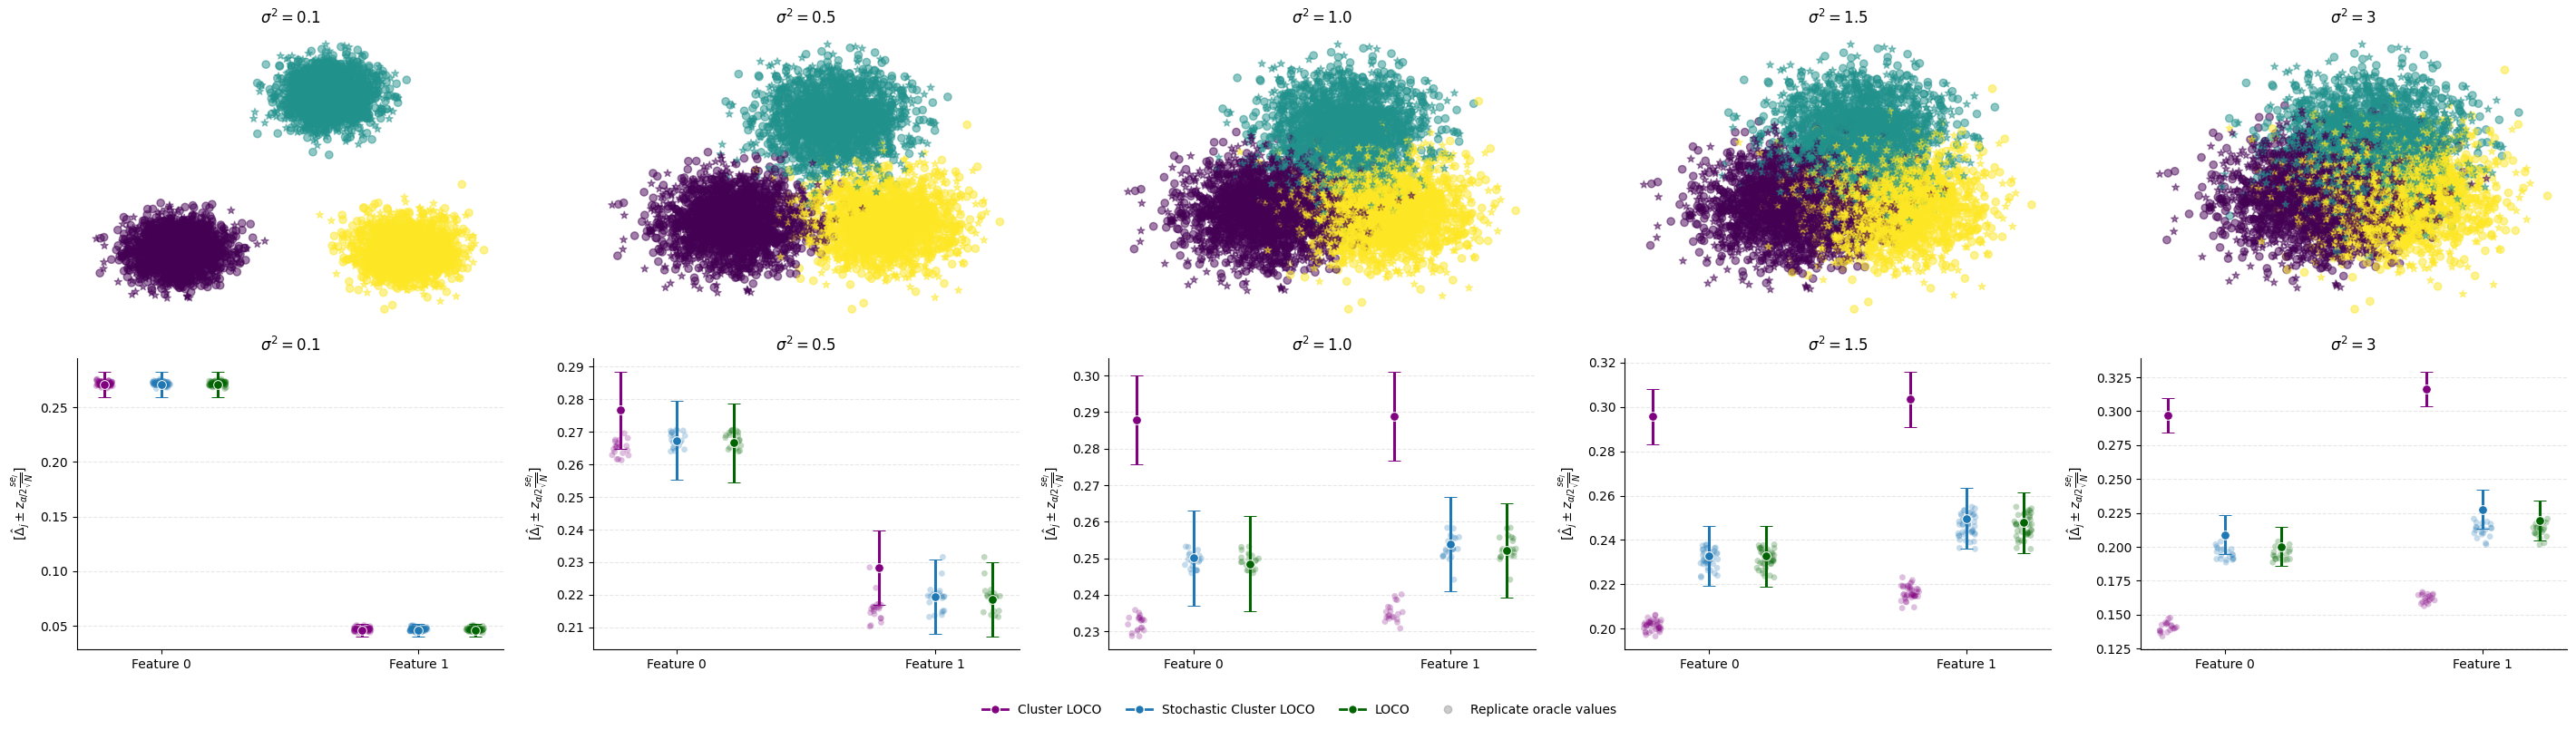

In [245]:
import sys
sys.path.append('../')
from simulations.mixture_models import sample_gmm
from sklearn.model_selection import train_test_split
K = 3
means = np.array([[1, 1], [3, 4], [4, 1]])
base_covariances = np.array([np.eye(2) for _ in range(K)])
weights = np.ones(K) / K
color_map = {"Cluster LOCO": "purple", "Stochastic Cluster LOCO": "tab:blue", "LOCO": "darkgreen"}
method_order = ["Cluster LOCO", "Stochastic Cluster LOCO", "LOCO"]
offsets = dict(zip(method_order, np.linspace(-0.22, 0.22, len(method_order))))
features = [0, 1]
rng = np.random.default_rng(24)
N = 2000
var_list = [0.1, 0.5, 1.0, 1.5, 3]
fig, ax = plt.subplots(2, len(var_list), figsize=(30, 8))

for i, var in enumerate(var_list):
    covariances = base_covariances * var
    X, Y = sample_gmm(means=means, covariances=covariances, weights=weights, n_samples=K * N, seed=234)
    x_tr, x_ca,  y_tr, y_ca = train_test_split(X, Y, test_size=0.5, random_state=634)
    ax[0, i].scatter(x_tr[:, 0], x_tr[:, 1], c=y_tr, label='train', alpha=0.5)
    ax[0, i].scatter(x_ca[:, 0], x_ca[:, 1], c=y_ca, label='calibration', alpha=0.5, marker='*')
    ax[0, i].set_title(rf"$\sigma^2 = {{{var}}}$")
    ax[0, i].axis('off')
    plot_df = raw_df[(raw_df.variance == var) & (raw_df.N == N)]
    legend_handles = plot_interval_oracle(plot_df, ax=ax[1, i], title=rf'$\sigma^2={var}$', color_map=color_map)
    ax[1, i].set_ylabel(r"$[\hat \Delta_j \pm z_{{\alpha/2}} \frac{se_{j}}{\sqrt{{N}}}]$")
fig.legend(handles=legend_handles, frameon=False, ncols=4, bbox_to_anchor=(0.6, -0.01))

fig.tight_layout(rect=[0.0, 0.0, 0.95, 0.95])
